# CatBoost Algorithm

CatBoost is a state-of-the-art open-source gradient boosting library based on decision trees. It is developed by Yandex researchers and engineers and is used for various tasks such as:
- Search
- Recommendation systems
- Personal assistants
- Self-driving cars
- Weather prediction

## Key Features:
- **Integration**: Designed to be integrated into data science pipelines.
- **Categorical Features**: CatBoost handles categorical features natively without requiring encoding before training the model.
- **Efficiency**: Provides a fast and scalable multi-threaded implementation of the algorithm.
- **Visualization Tools**: Offers powerful visualization tools to understand the model.

CatBoost delivers state-of-the-art results and is particularly powerful in handling categorical features efficiently.

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# data import titanic
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [4]:
# impute missing values using knn imputers in age
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df['age'] = imputer.fit_transform(df[['age']])

# impute embarked missing values using pandas
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
# drop deck column
df.drop('deck', axis=1, inplace=True)

# df missing values
df.isnull().sum().sort_values(ascending=False)


survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  891 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 79.4+ KB


In [6]:
df = df.drop(['alive'], axis=1)
# convert each category/object column to category
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
# add this as a new column in the dataframe
df[categorical_cols] = df[categorical_cols].astype('category')

In [7]:
df.dtypes

survived          int64
pclass            int64
sex            category
age             float64
sibsp             int64
parch             int64
fare            float64
embarked       category
class          category
who            category
adult_male         bool
embark_town    category
alone              bool
dtype: object

In [8]:

# split data into X and y
X = df.drop('survived', axis=1)
y = df['survived']

# split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Accuracy Score: 0.820627802690583
Confusion Matrix: 
 [[119  15]
 [ 25  64]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.83      0.89      0.86       134
           1       0.81      0.72      0.76        89

    accuracy                           0.82       223
   macro avg       0.82      0.80      0.81       223
weighted avg       0.82      0.82      0.82       223

CPU times: total: 1min 24s
Wall time: 32.6 s
CPU times: total: 1min 24s
Wall time: 32.6 s


Text(0.5, 1.0, 'Confusion Matrix')

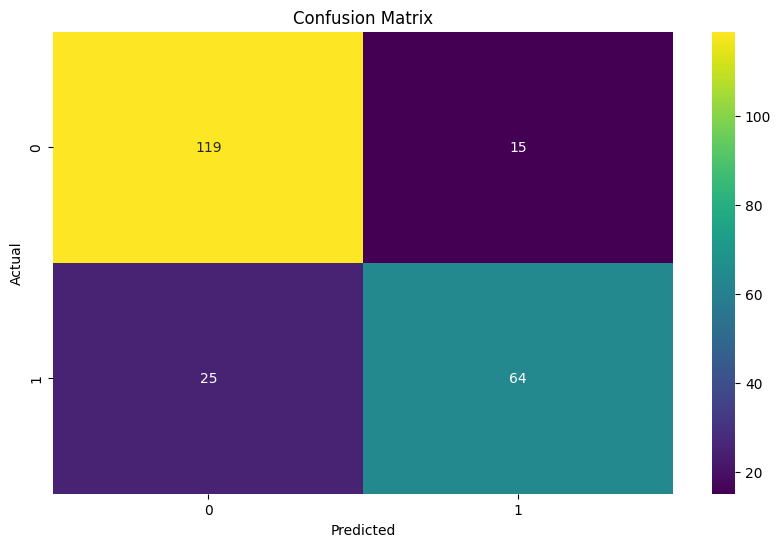

In [9]:
%%time
# run the catboost classifier
model = CatBoostClassifier(iterations=1000,
                           learning_rate=0.001,
                           depth=3,
                           loss_function='Logloss',
                           eval_metric='Accuracy',
                           random_seed=42,
                           verbose=False)

# train the model
model.fit(X_train, y_train, cat_features=categorical_cols.tolist())

# predictions
y_pred = model.predict(X_test)

# evaluate the model
print(f'Accuracy Score: {accuracy_score(y_test, y_pred)}')
print(f'Confusion Matrix: \n {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: \n {classification_report(y_test, y_pred)}')

# plot confusion matrix
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='viridis')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

This cell performs the following steps:

1. **Model Initialization**:  
    A `CatBoostClassifier` is created with specific hyperparameters:
    - `iterations=1000`: Number of boosting iterations.
    - `learning_rate=0.001`: Step size shrinkage used in update to prevent overfitting.
    - `depth=3`: Depth of each tree.
    - `loss_function='Logloss'`: Logarithmic loss for binary classification.
    - `eval_metric='Accuracy'`: Accuracy metric for evaluation.
    - `random_seed=42`: Seed for reproducibility.
    - `verbose=False`: Suppresses training output.

2. **Model Training**:  
    The model is trained using the training data (`X_train`, `y_train`). The `cat_features` parameter specifies which columns are categorical.

3. **Prediction**:  
    The trained model predicts the target variable for the test set (`X_test`).

4. **Evaluation**:  
    - **Accuracy Score**: Prints the accuracy of the model on the test set.
    - **Confusion Matrix**: Prints the confusion matrix to show the number of correct and incorrect predictions.
    - **Classification Report**: Prints precision, recall, f1-score, and support for each class.

5. **Visualization**:  
    Plots the confusion matrix as a heatmap for better visualization of the model's performance.

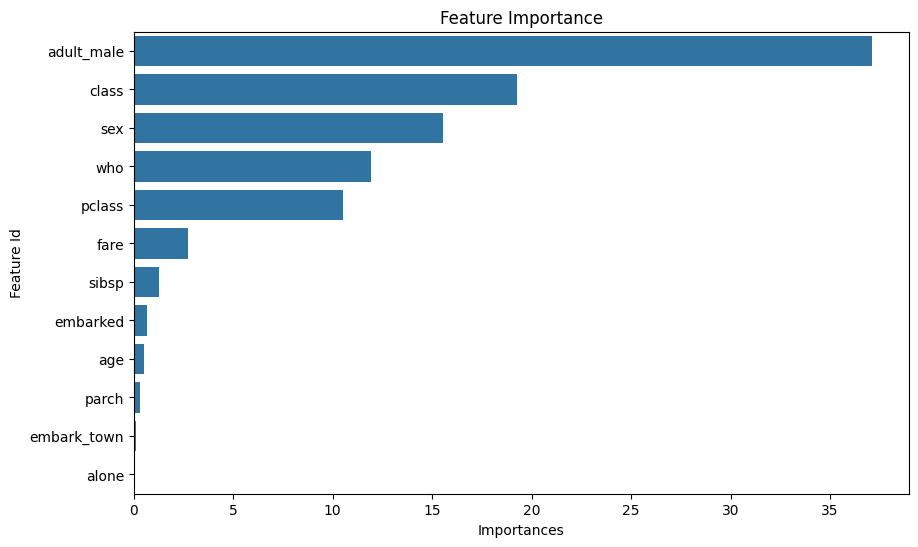

In [10]:
# feature importance
feature_importance = model.get_feature_importance(prettified=True)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importances', y='Feature Id', data=feature_importance)
plt.title('Feature Importance')
plt.show()

1. **Model Initialization**:  
    - A `CatBoostClassifier` is created with specific hyperparameters:
      - `iterations=1000`: Number of boosting rounds (trees).
      - `learning_rate=0.001`: Controls the step size at each iteration.
      - `depth=3`: Maximum depth of each tree.
      - `loss_function='Logloss'`: Suitable for binary classification.
      - `eval_metric='Accuracy'`: Uses accuracy to evaluate model performance.
      - `random_seed=42`: Ensures reproducibility.
      - `verbose=False`: Suppresses training output.

2. **Model Training**:  
    - The model is trained using the training data (`X_train`, `y_train`).
    - The `cat_features` parameter tells CatBoost which columns are categorical.

3. **Prediction**:  
    - The trained model predicts the target variable (`survived`) for the test set (`X_test`).

4. **Evaluation**:  
    - **Accuracy Score**: Prints the accuracy of predictions on the test set.
    - **Confusion Matrix**: Shows the number of correct and incorrect predictions for each class.
    - **Classification Report**: Displays precision, recall, f1-score, and support for each class.

5. **Visualization**:  
    - Plots the confusion matrix as a heatmap for easier interpretation of model performance.

# About the Author

<div style="background-color: #f8f9fa; border-left: 5px solid #28a745; padding: 20px; margin-bottom: 20px; border-radius: 5px;">
  <h2 style="color: #28a745; margin-top: 0; font-family: 'Poppins', sans-serif;">Muhammad Atif Latif</h2>
  <p style="font-size: 16px; color: #495057;">Data Scientist & Machine Learning Engineer</p>
  
  <p style="font-size: 15px; color: #6c757d; margin-top: 15px;">
    Passionate about building AI solutions that solve real-world problems. Specialized in machine learning, 
    deep learning, and data analytics with experience implementing production-ready models.
  </p>
</div>

## Connect With Me

<div style="display: flex; flex-wrap: wrap; gap: 10px; margin-top: 15px;">
  <a href="https://github.com/m-Atif-Latif" target="_blank">
    <img src="https://img.shields.io/badge/GitHub-Follow-212121?style=for-the-badge&logo=github" alt="GitHub">
  </a>
  <a href="https://www.kaggle.com/matiflatif" target="_blank">
    <img src="https://img.shields.io/badge/Kaggle-Profile-20BEFF?style=for-the-badge&logo=kaggle" alt="Kaggle">
  </a>
  <a href="https://www.linkedin.com/in/muhammad-atif-latif-13a171318" target="_blank">
    <img src="https://img.shields.io/badge/LinkedIn-Connect-0077B5?style=for-the-badge&logo=linkedin" alt="LinkedIn">
  </a>
  <a href="https://x.com/mianatif5867" target="_blank">
    <img src="https://img.shields.io/badge/Twitter-Follow-1DA1F2?style=for-the-badge&logo=twitter" alt="Twitter">
  </a>
  <a href="https://www.instagram.com/its_atif_ai/" target="_blank">
    <img src="https://img.shields.io/badge/Instagram-Follow-E4405F?style=for-the-badge&logo=instagram" alt="Instagram">
  </a>
  <a href="mailto:muhammadatiflatif67@gmail.com">
    <img src="https://img.shields.io/badge/Email-Contact-D14836?style=for-the-badge&logo=gmail" alt="Email">
  </a>
</div>

---